In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import statsmodels.api as sm
from scipy.stats import scoreatpercentile, percentileofscore
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, f1_score

In [2]:
def calc_metrics(y_true, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=np.array([0,1])).ravel()
    
    return pd.DataFrame({'acc': accuracy_score(y_true, pred),
                         'f1': f1_score(y_true, pred),
                         'tn': tn,
                         'fp': fp,
                         'fn': fn,
                         'tp': tp}, index=np.array([0]))

def summary_table(df):
    result_dict = {}
    uniq_df =  df[['curve_idx','groundtruth_label']].drop_duplicates().reset_index()
    result_dict['n_curves'] = uniq_df.curve_idx.nunique()
    result_dict['pos_perc'] = uniq_df.groundtruth_label.sum()/uniq_df.shape[0]
    
    try:
        result_dict['n_sample'] = df.sample_id.nunique()
    except:
        return pd.DataFrame(result_dict, index=[0])
    
    return pd.DataFrame(result_dict, index=[0])

In [3]:
old_data_dir = '/media/ssd1/huong/PCR-huong/data'
new_data_dir = os.path.join(old_data_dir, 'new_data')
old_modeloutput_dir = os.path.join(old_data_dir, 'model_outputs')
new_modeloutput_dir = os.path.join(new_data_dir, 'model_outputs')

In [4]:
# old_groundtruth = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))
# old_groundtruth_test_water_ids = old_groundtruth[(old_groundtruth.split == 'test') & (old_groundtruth.sample_type == 'Negative Control (qPCR)')].sample_id.unique()
# new_groundtruth_test_water_ids = groundtruth_df[(groundtruth_df.split == 'test') & (groundtruth_df.sample_type == 'Negative Control (qPCR)')].sample_id.unique()

# [i for i in old_groundtruth_test_water_ids if i in new_groundtruth_test_water_ids]

In [5]:
water_well_ids = ['S624960', 'S993281', 'S1122933', 'S897698', 
                  'S1262658', 'S1168204', 'S184660', 'S1270893']

In [6]:
known_df = pd.read_csv(os.path.join(old_data_dir, 'known_dilution_data.csv'))
karlen_df = pd.read_csv(os.path.join(old_data_dir, 'qpcr_karlen.csv'))
karlen_df['groundtruth_label'] = 1
karlen_df['curve_idx'] = karlen_df.curve_idx + '_' + karlen_df.data_set
karlen_df['inv_dilution_fold'] = 1/karlen_df.dilution_fold
chip60_df = pd.read_csv(os.path.join(old_data_dir, 'chipPCR_C60amp.csv'))
chip60_df['groundtruth_label'] = 1*(chip60_df.dilution != 0)

chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))

karlen_qpcr_pred = pd.DataFrame()
for i in range(1,4):
    df = pd.read_csv(os.path.join(old_modeloutput_dir, f'qpcr_karlen{i}_pred.csv'))
    df['curve_idx'] = df['curve_idx'] + f'_karlen{i}'
    karlen_qpcr_pred = pd.concat([karlen_qpcr_pred, df])

karlen_qpcr_pred = karlen_qpcr_pred.reset_index()

known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))


In [7]:
## old data

# known_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_known_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_karlen_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_chip60_pred_df.csv'))

known_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_known_pred_df.csv'))
karlen_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_karlen_pred_df.csv'))
chip60_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'fusion_vit_delta64_chip60_pred_df.csv'))

# known_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_known_pred.csv'))
# chip60_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_chip60_pred.csv'))
# test_qpcr_pred = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))

curve_df = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='curve_data')
sample_info = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='sample_info')
igi_gene_call = pd.read_hdf('/media/ssd1/huong/PCR-huong/data/data.h5', key='igi_gene_call')

join_df = (curve_df
           .merge(sample_info, how='inner', on=['well_position','pcr_plate'])
           .merge(igi_gene_call, how ='inner', on=['pcr_plate','sample_id','target']))
thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
join_df['test_kit'] = 'LuNER'
join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'



In [8]:
qpcr_known_test = pd.read_csv(os.path.join(old_modeloutput_dir, 'qpcr_groundtruth_pred.csv'))
qpcr_known_water = (qpcr_known_test[qpcr_known_test.split == 'test']
                   .merge(join_df.loc[(join_df.cycle_no == 1) & (join_df.sample_id.isin(water_well_ids)), ['curve_idx']],
                          on='curve_idx'))
qpcr_known_water['dilution_level'] = 0
qpcr_known_pred_df = pd.concat([(known_qpcr_pred
                      .merge(known_df.loc[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP'), ['curve_idx','dilution_level']], 
                             on='curve_idx')),
                                qpcr_known_water[['curve_idx','eff','groundtruth_label','prob','dilution_level']]])



In [9]:
# known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_known_val_test_pred_df.csv'))
# karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_karlen_val_test_pred_df.csv'))
# chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'3_20_ImageModel_large_no_invalid_chip60_val_test_pred_df.csv'))

# # known_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'4_3_fusiongene_large_no_invalid_known_val_test_pred_df.csv'))
# # karlen_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'4_3_fusiongene_large_no_invalid_karlen_val_test_pred_df.csv'))
# # chip60_pred = pd.read_csv(os.path.join(new_modeloutput_dir,'4_3_fusiongene_large_no_invalid_chip60_val_test_pred_df.csv'))

# join_df = pd.read_pickle(os.path.join(new_data_dir, 'new_join_df_1.pkl'))
# thermo_sample_ids = join_df[join_df.target == 'MS2'].sample_id.unique()
# join_df['test_kit'] = 'LuNER'
# join_df.loc[join_df.sample_id.isin(thermo_sample_ids),'test_kit'] = 'Thermo'


In [10]:
# test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'experimental', 'seq_test_pred_df.csv'))
test_pred = pd.read_csv(os.path.join(old_modeloutput_dir,'fusion_vit_delta64_test_pred_df.csv'))
groundtruth_df = pd.read_csv(os.path.join(old_data_dir, 'groundtruth_df_target_data_split_v2.csv'))

test_pred = (test_pred
             .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
                    on='curve_idx')
             .merge(groundtruth_df.loc[groundtruth_df.split == 'test', 
                                       ['curve_idx','sample_id','target','igi_call','groundtruth']],
                    on='curve_idx')
             )

# test_pred = pd.read_csv(os.path.join(new_modeloutput_dir, '3_20_ImageModel_large_no_invalid_groundtruth_val_test_pred_df.csv'))
# test_pred = test_pred[test_pred.split == 'test']
# groundtruth_df = pd.read_csv(os.path.join(new_data_dir, 'new_groundtruth_df_no_invalid.csv'))

# test_pred = (test_pred
#              .merge(join_df.loc[join_df.cycle_no == 40,['curve_idx','well_position']],
#                     on='curve_idx')
#              .merge(groundtruth_df
#                     .loc[groundtruth_df.cycle_no == 40,
#                          ['curve_idx','sample_id','target','igi_call','groundtruth']],
#                     on='curve_idx')
#              )

test_pred['encoded_igi_call'] = 1*(test_pred.igi_call == 'Positive')
test_pred['groundtruth_label'] = 1*(test_pred.groundtruth == 1)

In [11]:
# best_test_acc_thres = 0.529 # old seq
# best_test_acc_thres = 0.51 #image new
best_test_acc_thres = 0.566 # fusion
best_qpcr_test_acc_thres = 0.522 

water_output_df = (test_pred.loc[test_pred.sample_id.isin(water_well_ids),
                                ['curve_idx','sample_id','groundtruth_label','outputs','target','encoded_igi_call']]
                   .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                   .rename(columns={'encoded_igi_call':'new_igi_call',
                                    'groundtruth_label':'groundtruth_target',
                                    'sample_id':'well_position'})
                   .reset_index())
water_output_df['dilution_level'] = 0
water_output_df['pred'] = 1*(water_output_df.outputs >= best_test_acc_thres)
water_output_df['qpcr_pred'] = 1*(water_output_df.prob >= best_qpcr_test_acc_thres)
print(water_output_df.shape)

(25, 11)


In [12]:


boxplot_known_df = known_df[(known_df.cycle_no == 1) & (known_df.target != 'RnaseP')].copy()
boxplot_known_df['new_igi_call'] = 1*(boxplot_known_df.amp_status == 'Amp')
boxplot_known_df = (boxplot_known_df
                    .merge(known_pred, on='curve_idx')
                    .merge(qpcr_known_pred_df[['curve_idx','prob']], on='curve_idx')
                    # .rename(columns={'groundtruth_label':'groundtruth_target'})
                    )
boxplot_known_df['pred'] = 1*(boxplot_known_df.outputs >= best_test_acc_thres)
boxplot_known_df['qpcr_pred'] = 1*(boxplot_known_df.prob >= best_qpcr_test_acc_thres)
# boxplot_known_df['temp'] = boxplot_known_df.drn >= boxplot_known_df.threshold
# boxplot_known_df['new_igi_call'] = 0
# known_thres_df = boxplot_known_df[boxplot_known_df.temp == 1].groupby('curve_idx').cycle_no.min().reset_index()
# for idx in boxplot_known_df.curve_idx.unique():
#     if boxplot_known_df[boxplot_known_df.curve_idx == idx].target.unique() == 'RnaseP':
#         boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 35)
#     else:
#         boxplot_known_df.loc[boxplot_known_df.curve_idx == idx, 'new_igi_call'] = 1*(known_thres_df[known_thres_df.curve_idx == idx].cycle_no.mean() < 40)


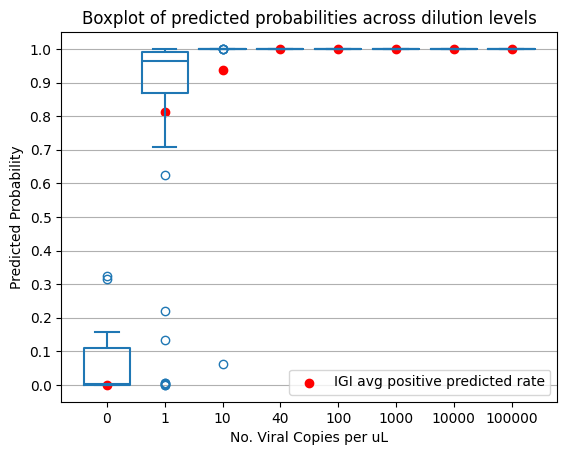

In [13]:
# boxplot_df = pd.concat([known_pred_df[['dilution_level','outputs']], water_output_df[['dilution_level','outputs']]], axis=0)
boxplot_df = pd.concat([boxplot_known_df[['curve_idx','well_position','dilution_level','outputs','pred','new_igi_call','prob','qpcr_pred']], 
                        water_output_df[['curve_idx','well_position','dilution_level','outputs','pred','new_igi_call','prob','qpcr_pred']]], axis=0)

sns.boxplot(data=boxplot_df, x='dilution_level', y = 'outputs', fill = False)
plt.scatter(0, water_output_df.groupby('curve_idx').new_igi_call.mean().mean(), color = 'red', label = 'IGI avg positive predicted rate')
plt.scatter(1, boxplot_known_df[boxplot_known_df.dilution_level == 1].new_igi_call.mean(), color = 'red')
plt.scatter(2, boxplot_known_df[boxplot_known_df.dilution_level == 10].new_igi_call.mean(), color = 'red')
plt.scatter(3, boxplot_known_df[boxplot_known_df.dilution_level == 40].new_igi_call.mean(), color = 'red')
plt.scatter(4, boxplot_known_df[boxplot_known_df.dilution_level == 100].new_igi_call.mean(), color = 'red')
plt.scatter(5, boxplot_known_df[boxplot_known_df.dilution_level == 1000].new_igi_call.mean(), color = 'red')
plt.scatter(6, boxplot_known_df[boxplot_known_df.dilution_level == 10000].new_igi_call.mean(), color = 'red')
plt.scatter(7, boxplot_known_df[boxplot_known_df.dilution_level == 100000].new_igi_call.mean(), color = 'red')

plt.title('Boxplot of predicted probabilities across dilution levels')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('No. Viral Copies per uL')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

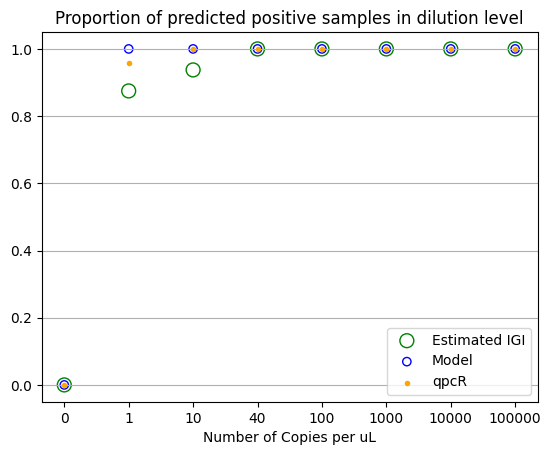

In [14]:

known_sampled_pred = (boxplot_df
                      .groupby(['dilution_level', 'well_position'])
                      .agg(sample_pred = ('pred', 'mean'),
                           sample_igi_call = ('new_igi_call', 'mean'),
                           sample_qpcr_pred = ('qpcr_pred','mean'))
                      .reset_index())
known_sampled_pred['sample_pred'] = 1*(known_sampled_pred.sample_pred >= 0.5)
known_sampled_pred['sample_igi_call'] = 1*(known_sampled_pred.sample_igi_call >= 0.5)
known_sampled_pred['sample_qpcr_pred'] = 1*(known_sampled_pred.sample_qpcr_pred >= 0.5)

pos_known_pred = known_sampled_pred.groupby('dilution_level')[['sample_igi_call','sample_pred','sample_qpcr_pred']].apply(lambda x: x.sum()/len(x)).reset_index()
pos_known_pred['dilution_level'] = pos_known_pred['dilution_level'].astype('str')

plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_igi_call', facecolor='none', edgecolors='green', s = 100)
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_pred', facecolor='none', edgecolor = 'blue')
plt.scatter(data=pos_known_pred,
             x='dilution_level', y='sample_qpcr_pred', color = 'orange', marker='.')
# plt.scatter(x=pos_known_pred.dilution_level, y='qpcr_pred', marker='x')
plt.legend(labels=['Estimated IGI', 'Model','qpcR'])
plt.title('Proportion of predicted positive samples in dilution level')
plt.xlabel('Number of Copies per uL')
plt.grid(axis='y')
plt.show()

In [15]:
boxplot_df['groundtruth_label'] = 1*(boxplot_df.dilution_level != 0)
known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.outputs)
print('Model AUC on known:', known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.pred)

Model AUC on known: 0.9820833333333332


,acc,f1,tn,fp,fn,tp
0,0.963134,0.978723,25,0,8,184


In [16]:

igi_known_auc = roc_auc_score(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)
print('IGI AUC on known:', igi_known_auc)
calc_metrics(boxplot_df.groundtruth_label, boxplot_df.new_igi_call)

IGI AUC on known: 0.9713541666666667


,acc,f1,tn,fp,fn,tp
0,0.949309,0.970509,25,0,11,181


In [17]:
print(known_sampled_pred.well_position.nunique())
summary_table(boxplot_df)

104


,n_curves,pos_perc
0,217,0.884793


### chip60

In [18]:
chip60_pred_df = (chip60_pred
                  .merge(chip60_df[chip60_df['Index'] == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

chip60_boxplot = (chip60_pred_df[['curve_idx','dilution','groundtruth_label','outputs']]
                  .merge(chip60_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .melt(id_vars=['curve_idx','dilution','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
chip60_boxplot['model'] = chip60_boxplot.model.replace({'outputs':'model',
                                                        'prob':'qpcR'})

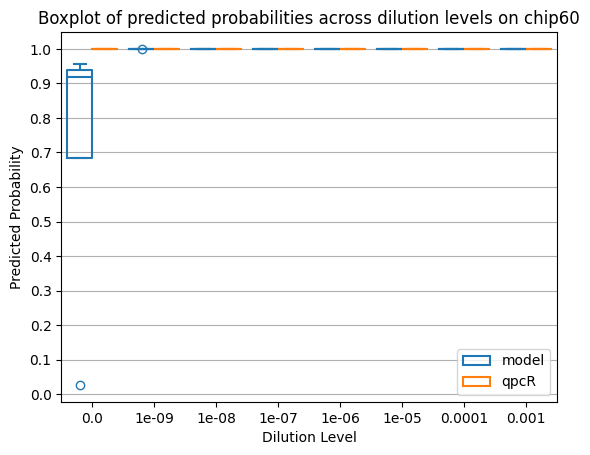

In [19]:
sns.boxplot(data=chip60_boxplot, x='dilution', y = 'predicted_score', hue='model', fill = False)

# plt.axhline(y=best_test_acc_thres, color='blue', linestyle = '--')
# plt.text(x=4, y = best_test_acc_thres - 0.05, s='Best accuracy threshold on test set', c='blue', size=8)

plt.title('Boxplot of predicted probabilities across dilution levels on chip60')
plt.yticks(np.arange(0,1.1,0.1))
plt.xlabel('Dilution Level')
plt.ylabel('Predicted Probability')
plt.grid(axis='y')
plt.legend()

In [20]:
chip60_boxplot['pred'] = 0
chip60_boxplot.loc[chip60_boxplot.model == 'model', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_test_acc_thres)
chip60_boxplot.loc[chip60_boxplot.model == 'qpcR', 'pred'] = 1*(chip60_boxplot.predicted_score >= best_qpcr_test_acc_thres)
                   
chip60_avg_pred_score = chip60_boxplot.groupby(['dilution','model'])[['groundtruth_label','pred']].apply(lambda x: accuracy_score(x.groundtruth_label, x.pred)).reset_index()
chip60_avg_pred_score.columns = ['dilution','model','accuracy_score']
chip60_avg_pred_score['dilution'] = chip60_avg_pred_score.dilution.astype('str')

Text(0.5, 1.0, 'Accuracy by Dilution Levels on chip60')

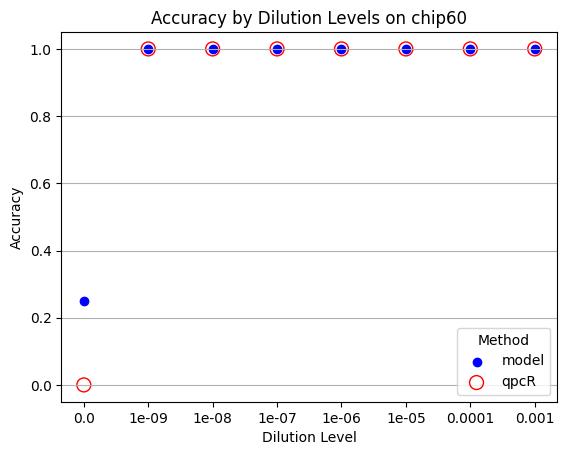

In [21]:
plt.scatter(chip60_avg_pred_score[chip60_avg_pred_score.model == 'model'].dilution, 
            chip60_avg_pred_score[chip60_avg_pred_score.model == 'model'].accuracy_score, c = 'blue', label='model')
plt.scatter(chip60_avg_pred_score[chip60_avg_pred_score.model == 'qpcR'].dilution, 
            chip60_avg_pred_score[chip60_avg_pred_score.model == 'qpcR'].accuracy_score, 
            s=100, facecolor='none', edgecolors='red', label='qpcR')
plt.xlabel('Dilution Level')
plt.ylabel('Accuracy')
plt.legend(title='Method')
plt.grid(axis='y')
plt.title('Accuracy by Dilution Levels on chip60')

In [22]:

model_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'model'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'model'].predicted_score)
print('Model AUC on chip60:', model_chip_auc)
chip60_boxplot['model_pred'] = 1*(chip60_boxplot.predicted_score >= best_test_acc_thres)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'model'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'model'].model_pred)

Model AUC on chip60: 1.0


,acc,f1,tn,fp,fn,tp
0,0.90625,0.949153,1,3,0,28


In [23]:

qpcr_chip_auc = roc_auc_score(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
                             chip60_boxplot[chip60_boxplot.model == 'qpcR'].predicted_score)
print('qpcR AUC on karlen:', qpcr_chip_auc)
chip60_boxplot['qpcr_pred'] = 1*(chip60_boxplot.predicted_score >= 0.5)
calc_metrics(chip60_boxplot[chip60_boxplot.model == 'qpcR'].groundtruth_label, 
             chip60_boxplot[chip60_boxplot.model == 'qpcR'].qpcr_pred)

qpcR AUC on karlen: 0.5


,acc,f1,tn,fp,fn,tp
0,0.875,0.933333,0,4,0,28


In [24]:
summary_table(chip60_boxplot)

,n_curves,pos_perc
0,32,0.875


### karlen

In [25]:
karlen_pred_df = (karlen_pred
                  .merge(karlen_df[karlen_df.Cycles == 1], on = 'curve_idx')
                  .rename(columns={'groundtruth_target':'groundtruth_label'})
                  )

karlen_boxplot = (karlen_pred_df[['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label','outputs']]
                  .merge(karlen_qpcr_pred[['curve_idx', 'prob']], on='curve_idx')
                  .melt(id_vars=['curve_idx','inv_dilution_fold','dilution_fold','groundtruth_label'], var_name='model',
                        value_name='predicted_score')
                  )
karlen_boxplot['model'] = karlen_boxplot.model.replace({'outputs':'model',
                                                        'prob':'qpcR'})
# karlen_boxplot['inv_dilution_fold'] = 1/karlen_boxplot.dilution_fold
# karlen_boxplot['inv_dilution_fold'] = karlen_boxplot.inv_dilution_fold.astype('str')

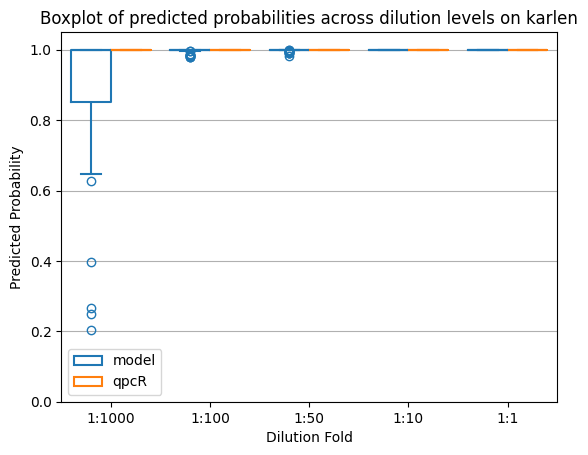

In [26]:
sns.boxplot(data=karlen_boxplot, x='inv_dilution_fold', y = 'predicted_score', hue='model', fill = False)

# plt.axhline(y=best_test_acc_thres, color='blue', linestyle = '--')
# plt.text(x=0, y = best_test_acc_thres - 0.05, s='Best accuracy threshold on test set', c='blue', size=8)

plt.title('Boxplot of predicted probabilities across dilution levels on karlen')
plt.xlabel('Dilution Fold')
plt.xticks(ticks=range(5), labels=['1:' + str(d) for d in [1000, 100, 50, 10, 1]])
plt.ylabel('Predicted Probability')
plt.ylim(0,1.05)
plt.grid(axis='y')
plt.legend()

Text(0.5, 1.0, 'Accuracy by Dilution Levels on karlen')

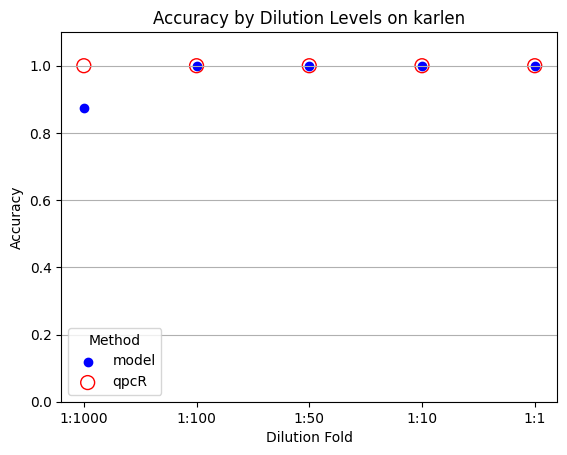

In [27]:
karlen_boxplot['pred'] = 0
karlen_boxplot.loc[karlen_boxplot.model == 'model', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_test_acc_thres)
karlen_boxplot.loc[karlen_boxplot.model == 'qpcR', 'pred'] = 1*(karlen_boxplot.predicted_score >= best_qpcr_test_acc_thres)
                   
karlen_avg_pred_score = (karlen_boxplot
                         .groupby(['inv_dilution_fold','dilution_fold','model'])[['groundtruth_label','pred']]
                         .apply(lambda x: accuracy_score(x.groundtruth_label, x.pred)).reset_index())
karlen_avg_pred_score.columns = ['inv_dilution_fold','dilution_fold','model','accuracy_score']

plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'model'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'model'].accuracy_score, c = 'blue', label='model')
plt.scatter(karlen_avg_pred_score[karlen_avg_pred_score.model == 'qpcR'].inv_dilution_fold.astype(str), 
            karlen_avg_pred_score[karlen_avg_pred_score.model == 'qpcR'].accuracy_score, 
            s=100, facecolor='none', edgecolors='red', label='qpcR')
plt.xlabel('Dilution Fold')
plt.xticks(ticks=range(len(karlen_avg_pred_score.dilution_fold.unique())), labels=['1:' + str(d) for d in karlen_avg_pred_score.dilution_fold.unique()])
plt.ylabel('Accuracy')
plt.ylim(0,1.1)
plt.legend(title='Method')
plt.grid(axis='y')
plt.title('Accuracy by Dilution Levels on karlen')

### IGI Simulation
##### karlen

In [28]:
karlen_pred_full = karlen_pred.copy()
karlen_pred_full = (karlen_df
               .merge(karlen_pred_full[['curve_idx','outputs']], on='curve_idx'))

In [29]:
thermo_df = join_df[(join_df.test_kit == 'Thermo') & (join_df.cycle_no == 37)]
thermo_threshold_df = thermo_df.groupby('target').threshold.mean()

thermo_thres_perc_df = pd.DataFrame(thermo_threshold_df)
thermo_thres_perc_df['percentile'] = np.nan
for key in thermo_thres_perc_df.index:
    thermo_thres_perc_df.loc[key,'percentile'] = percentileofscore(thermo_df[thermo_df.target == key].drn, 
                                                         thermo_threshold_df[key], kind='weak')

threshold_40 = thermo_thres_perc_df.percentile.mean()

karlen_threshold = (karlen_pred_full[karlen_pred_full.Cycles == 37]
                    .groupby('data_set')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_40))
                    .reset_index(name='threshold'))

karlen_pred_full = (karlen_pred_full
             .merge(karlen_threshold, on = 'data_set'))

karlen_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_pred_full['pred'] = 1*(karlen_pred_full.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_pred_full.groundtruth_label, karlen_pred_full.pred, labels=np.array([0,1])).ravel()
    
    karlen_model_dict['thres'].append(i)
    karlen_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_model_dict['fnr'].append(fn/(fn+tp))
    karlen_model_dict['fpr'].append(fp/(fp+tn))
    karlen_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_model_dict_df = pd.DataFrame(karlen_model_dict)
    
karlen_thres_df = {'perc':[], 'cycle':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(31, 41):
        df = karlen_pred_full.copy()
        df['new_threshold'] = karlen_pred_full.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)

        tn, fp, fn, tp = confusion_matrix(df[df.Cycles == 1].groundtruth_label, df[df.Cycles == 1].new_igi_call, labels=np.array([0,1])).ravel()
        
        karlen_thres_df['perc'].append(perc)
        karlen_thres_df['cycle'].append(cycle)
        karlen_thres_df['fpr'].append(fp/(fp+tn))
        karlen_thres_df['fnr'].append(fn/(fn+tp))
        karlen_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))


/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].appe

In [30]:

karlen_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_qpcr_pred['pred'] = 1*(karlen_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_qpcr_pred.groundtruth_label, karlen_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_qpcr_dict['thres'].append(i)
    karlen_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_qpcr_dict['fnr'].append(fn/(fn+tp))
    karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
    karlen_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_qpcr_dict_df = pd.DataFrame(karlen_qpcr_dict)

/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))

/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))

True positive fraction: 1.0


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on karlen set')

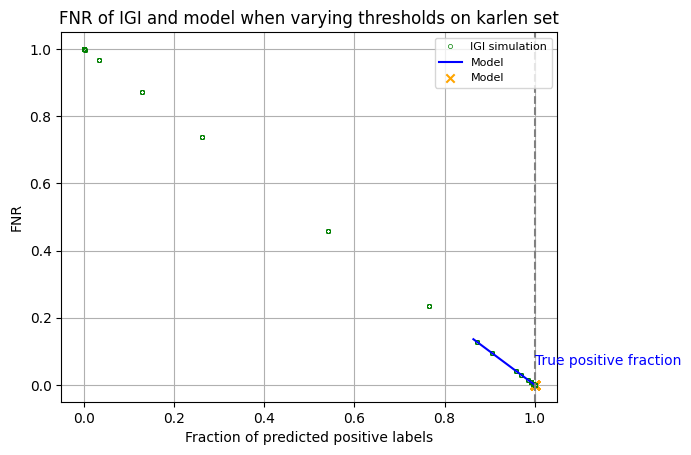

In [31]:
        
karlen_true_pos_frac = sum(karlen_pred_full.groundtruth_label == 1)/karlen_pred_full.shape[0]
print('True positive fraction:', karlen_true_pos_frac)
karlen_thres_df = pd.DataFrame(karlen_thres_df)
plt.plot(karlen_thres_df.pos_pred, 
         karlen_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'green','mew':0.5}, label='IGI simulation')

plt.plot(karlen_model_dict_df.pos_frac, karlen_model_dict_df.fnr, color='blue', label='Model')
plt.scatter(karlen_qpcr_dict_df.pos_frac, karlen_qpcr_dict_df.fnr, color='orange', marker='x', label='Model')
plt.axvline(karlen_true_pos_frac, linestyle='--', color='gray')
plt.text(x=karlen_true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on karlen set')

#### Chip60

In [53]:
chip60_pred_full = chip60_pred.copy()
chip60_pred_full = (chip60_pred_full
                    .merge(chip60_df, on='curve_idx'))

True positive fraction: 0.875


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on chip60 set')

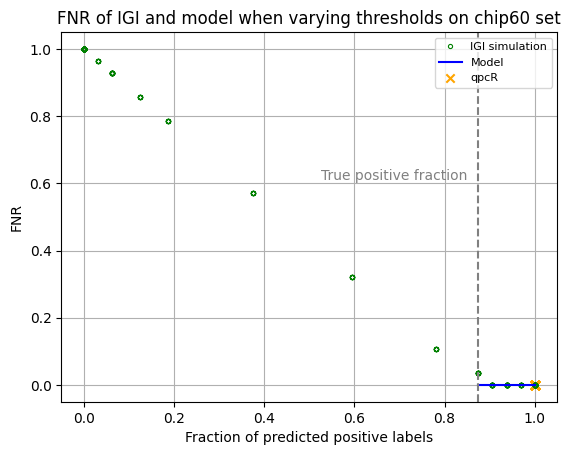

In [54]:
luner_df = join_df[(join_df.test_kit == 'LuNER') & (join_df.cycle_no == 40)]
luner_threshold_df = luner_df.groupby('target').threshold.mean()

luner_thres_perc_df = pd.DataFrame(luner_threshold_df)
luner_thres_perc_df['percentile'] = np.nan
for key in luner_thres_perc_df.index:
    luner_thres_perc_df.loc[key,'percentile'] = percentileofscore(luner_df[luner_df.target == key].drn, 
                                                         luner_threshold_df[key], kind='weak')

threshold_45 = luner_thres_perc_df.percentile.mean()

chip60_threshold = (chip60_pred_full[chip60_pred_full['Index'] == 40]
                    .groupby('sample')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_45))
                    .reset_index(name='threshold'))

chip60_pred_full_df = (chip60_pred_full
             .merge(chip60_threshold, on = 'sample'))

chip60_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_pred_full_df['pred'] = 1*(chip60_pred_full_df.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_pred_full_df.groundtruth_label, chip60_pred_full_df.pred, labels=np.array([0,1])).ravel()
    
    chip60_model_dict['thres'].append(i)
    chip60_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_model_dict['fnr'].append(fn/(fn+tp))
    chip60_model_dict['fpr'].append(fp/(fp+tn))
    chip60_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_model_dict_df = pd.DataFrame(chip60_model_dict)
    

chip60_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_qpcr_dict['thres'].append(i)
    chip60_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_qpcr_dict['fnr'].append(fn/(fn+tp))
    chip60_qpcr_dict['fpr'].append(fp/(fp+tn))
    chip60_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_qpcr_dict_df = pd.DataFrame(chip60_qpcr_dict)
    

chip60_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(35, 45):
        df = chip60_pred_full_df.copy()
        df['new_threshold'] = chip60_pred_full_df.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)
        df_1 = df[df['Index'] == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        chip60_thres_df['fpr'].append(fp/(fp+tn))
        chip60_thres_df['fnr'].append(fn/(fn+tp))
        chip60_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
chip60_true_pos_frac = sum(chip60_pred_full_df.groundtruth_label == 1)/chip60_pred_full_df.shape[0]
print('True positive fraction:', chip60_true_pos_frac)

chip60_thres_df = pd.DataFrame(chip60_thres_df)
plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fnr, color='blue', label='Model')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_model_dict_df.fnr, color='orange', marker='x', label='qpcR')
plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on chip60 set')

Text(0.5, 1.0, 'FPR of IGI and model when varying thresholds on chip60 set')

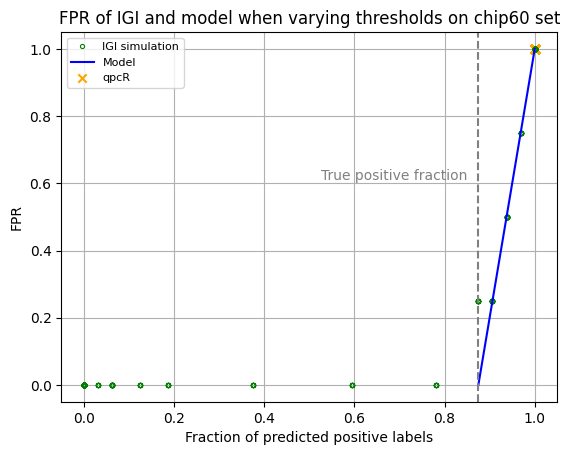

In [35]:
plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fpr, 
         '.', **{'mfc': 'none', 'mec':'green','mew':0.8}, label='IGI simulation')

# plt.plot(igi_pos_frac, igi_fpr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fpr, color='blue', label='Model')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_qpcr_dict_df.fpr, color='orange', marker='x', label='qpcR')
plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac - 0.35, y = 0.61, s='True positive fraction', c='gray')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FPR')
plt.legend(loc='upper left',fontsize=8)
plt.grid()
plt.title('FPR of IGI and model when varying thresholds on chip60 set')

### IGI Simulation
##### karlen

In [36]:
karlen_pred_full = karlen_pred.copy()
karlen_pred_full = (karlen_df
               .merge(karlen_pred_full[['curve_idx','outputs']], on='curve_idx'))

In [37]:
thermo_df = join_df[(join_df.test_kit == 'Thermo') & (join_df.cycle_no == 37)]
thermo_threshold_df = thermo_df.groupby('target').threshold.mean()

thermo_thres_perc_df = pd.DataFrame(thermo_threshold_df)
thermo_thres_perc_df['percentile'] = np.nan
for key in thermo_thres_perc_df.index:
    thermo_thres_perc_df.loc[key,'percentile'] = percentileofscore(thermo_df[thermo_df.target == key].drn, 
                                                         thermo_threshold_df[key], kind='weak')

threshold_40 = thermo_thres_perc_df.percentile.mean()

karlen_threshold = (karlen_pred_full[karlen_pred_full.Cycles == 37]
                    .groupby('data_set')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_40))
                    .reset_index(name='threshold'))

karlen_pred_full = (karlen_pred_full
             .merge(karlen_threshold, on = 'data_set'))

karlen_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_pred_full['pred'] = 1*(karlen_pred_full.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_pred_full.groundtruth_label, karlen_pred_full.pred, labels=np.array([0,1])).ravel()
    
    karlen_model_dict['thres'].append(i)
    karlen_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_model_dict['fnr'].append(fn/(fn+tp))
    karlen_model_dict['fpr'].append(fp/(fp+tn))
    karlen_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_model_dict_df = pd.DataFrame(karlen_model_dict)
    
karlen_thres_df = {'perc':[], 'cycle':[], 'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(31, 41):
        df = karlen_pred_full.copy()
        df['new_threshold'] = karlen_pred_full.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)

        tn, fp, fn, tp = confusion_matrix(df[df.Cycles == 1].groundtruth_label, df[df.Cycles == 1].new_igi_call, labels=np.array([0,1])).ravel()
        
        karlen_thres_df['perc'].append(perc)
        karlen_thres_df['cycle'].append(cycle)
        karlen_thres_df['fpr'].append(fp/(fp+tn))
        karlen_thres_df['fnr'].append(fn/(fn+tp))
        karlen_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))


/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1715639015.py:28: RuntimeWarning: invalid value encountered in scalar divide
  karlen_model_dict['fpr'].appe

In [38]:

karlen_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    karlen_qpcr_pred['pred'] = 1*(karlen_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(karlen_qpcr_pred.groundtruth_label, karlen_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    karlen_qpcr_dict['thres'].append(i)
    karlen_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    karlen_qpcr_dict['fnr'].append(fn/(fn+tp))
    karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
    karlen_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
karlen_qpcr_dict_df = pd.DataFrame(karlen_qpcr_dict)

/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))

/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))
/tmp/ipykernel_712805/1154766145.py:9: RuntimeWarning: invalid value encountered in scalar divide
  karlen_qpcr_dict['fpr'].append(fp/(fp+tn))

True positive fraction: 1.0


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on karlen set')

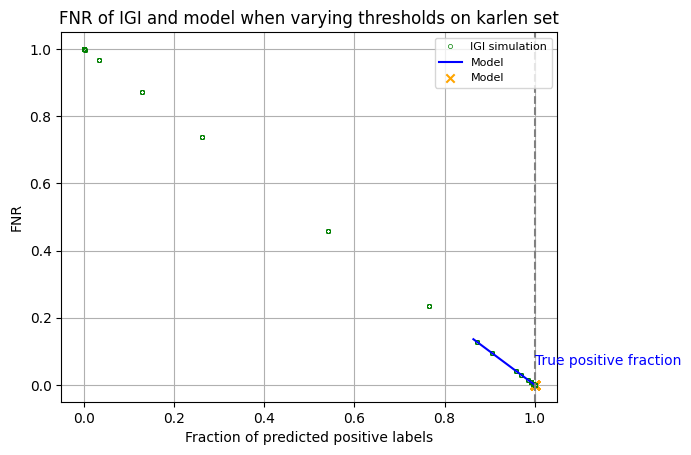

In [39]:
        
karlen_true_pos_frac = sum(karlen_pred_full.groundtruth_label == 1)/karlen_pred_full.shape[0]
print('True positive fraction:', karlen_true_pos_frac)
karlen_thres_df = pd.DataFrame(karlen_thres_df)
plt.plot(karlen_thres_df.pos_pred, 
         karlen_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'green','mew':0.5}, label='IGI simulation')

plt.plot(karlen_model_dict_df.pos_frac, karlen_model_dict_df.fnr, color='blue', label='Model')
plt.scatter(karlen_qpcr_dict_df.pos_frac, karlen_qpcr_dict_df.fnr, color='orange', marker='x', label='Model')
plt.axvline(karlen_true_pos_frac, linestyle='--', color='gray')
plt.text(x=karlen_true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on karlen set')

#### Chip60

In [40]:
chip60_pred_full = chip60_pred.copy()
chip60_pred_full = (chip60_pred_full
                    .merge(chip60_df, on='curve_idx'))

True positive fraction: 0.875


Text(0.5, 1.0, 'FNR of IGI and model when varying thresholds on chip60 set')

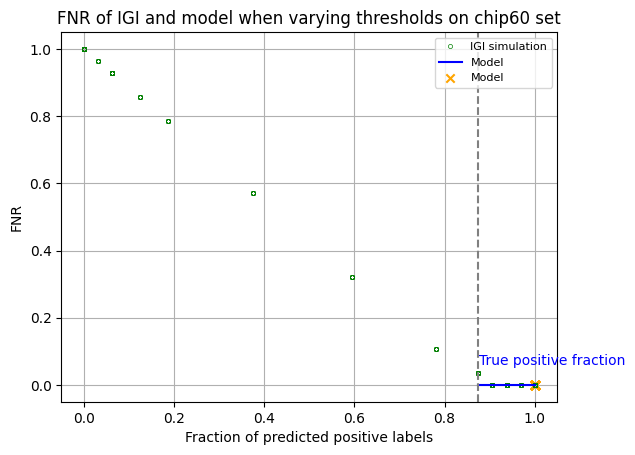

In [41]:
luner_df = join_df[(join_df.test_kit == 'LuNER') & (join_df.cycle_no == 40)]
luner_threshold_df = luner_df.groupby('target').threshold.mean()

luner_thres_perc_df = pd.DataFrame(luner_threshold_df)
luner_thres_perc_df['percentile'] = np.nan
for key in luner_thres_perc_df.index:
    luner_thres_perc_df.loc[key,'percentile'] = percentileofscore(luner_df[luner_df.target == key].drn, 
                                                         luner_threshold_df[key], kind='weak')

threshold_45 = luner_thres_perc_df.percentile.mean()

chip60_threshold = (chip60_pred_full[chip60_pred_full['Index'] == 40]
                    .groupby('sample')
                    .apply(lambda x: scoreatpercentile(x.Fn, threshold_45))
                    .reset_index(name='threshold'))

chip60_pred_full = (chip60_pred_full
             .merge(chip60_threshold, on = 'sample'))

chip60_model_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_pred_full['pred'] = 1*(chip60_pred_full.outputs >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_pred_full.groundtruth_label, chip60_pred_full.pred, labels=np.array([0,1])).ravel()
    
    chip60_model_dict['thres'].append(i)
    chip60_model_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_model_dict['fnr'].append(fn/(fn+tp))
    chip60_model_dict['fpr'].append(fp/(fp+tn))
    chip60_model_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_model_dict_df = pd.DataFrame(chip60_model_dict)
    

chip60_qpcr_dict = {'thres':[], 'acc':[],'fnr':[], 'fpr':[], 'pos_frac':[]}
for i in np.arange(0,1,0.001):
    chip60_qpcr_pred['pred'] = 1*(chip60_qpcr_pred.prob >= i)
    tn, fp, fn, tp = confusion_matrix(chip60_qpcr_pred.groundtruth_label, chip60_qpcr_pred.pred, labels=np.array([0,1])).ravel()
    
    chip60_qpcr_dict['thres'].append(i)
    chip60_qpcr_dict['acc'].append((tp+tn)/(tp+fp+tn+fn))
    chip60_qpcr_dict['fnr'].append(fn/(fn+tp))
    chip60_qpcr_dict['fpr'].append(fp/(fp+tn))
    chip60_qpcr_dict['pos_frac'].append((tp+fp)/(tp+fp+tn+fn))
    
chip60_qpcr_dict_df = pd.DataFrame(chip60_qpcr_dict)
    

chip60_thres_df = {'fpr':[], 'fnr':[], 'pos_pred': []}

for perc in np.arange(-.9, 0.9, 0.05):
    for cycle in range(35, 45):
        df = chip60_pred_full.copy()
        df['new_threshold'] = chip60_pred_full.threshold * (1 + perc)
        
        df['if_pass'] = df.Fn >= df.new_threshold
        passed_ids = df[df.if_pass].curve_idx.unique()
        df['new_ct'] = np.Inf
        df.loc[df.curve_idx.isin(passed_ids), 'new_ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')
        
        df['new_igi_call'] = 1*(df.new_ct <= cycle)
        df_1 = df[df['Index'] == 1]
        tn, fp, fn, tp = confusion_matrix(df_1.groundtruth_label, df_1.new_igi_call, labels=np.array([0,1])).ravel()
        
        chip60_thres_df['fpr'].append(fp/(fp+tn))
        chip60_thres_df['fnr'].append(fn/(fn+tp))
        chip60_thres_df['pos_pred'].append((fp+tp)/(fp+tp+tn+fn))
        
chip60_true_pos_frac = sum(chip60_pred_full.groundtruth_label == 1)/chip60_pred_full.shape[0]
print('True positive fraction:', chip60_true_pos_frac)

chip60_thres_df = pd.DataFrame(chip60_thres_df)
plt.plot(chip60_thres_df.pos_pred, 
         chip60_thres_df.fnr, 
         '.', **{'mfc': 'none', 'mec':'green','mew':0.5}, label='IGI simulation')

# plt.plot(igi_pos_frac, igi_fnr, 'x', color='red', **{'ms':7,'mew':2}, label='true IGI')

plt.plot(chip60_model_dict_df.pos_frac, chip60_model_dict_df.fnr, color='blue', label='Model')
plt.scatter(chip60_qpcr_dict_df.pos_frac, chip60_model_dict_df.fnr, color='orange', marker='x', label='Model')
plt.axvline(chip60_true_pos_frac, linestyle='--', color='gray')
plt.text(x=chip60_true_pos_frac + 0.001, y = 0.061, s='True positive fraction', c='blue')
# plt.xlim(0.855, 0.885)
# plt.ylim(-0.02,0.05)
plt.xlabel('Fraction of predicted positive labels')
plt.ylabel('FNR')
plt.legend(loc='upper right',fontsize=8)
plt.grid()
plt.title('FNR of IGI and model when varying thresholds on chip60 set')

### Regression Analysis
#### chip60

In [42]:
# lm_model = sm.OLS()
X = sm.add_constant(chip60_boxplot.loc[chip60_boxplot.model=='model', ['predicted_score']])
model_chip_lm = sm.OLS(chip60_boxplot.loc[chip60_boxplot.model=='model', ['dilution']], X)
results = model_chip_lm.fit()
print('Model chip60 regression')
print(results.summary())

Model chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                 -0.024
Method:                 Least Squares   F-statistic:                    0.2594
Date:                Thu, 11 Apr 2024   Prob (F-statistic):              0.614
Time:                        16:59:06   Log-Likelihood:                 211.54
No. Observations:                  32   AIC:                            -419.1
Df Residuals:                      30   BIC:                            -416.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const           -3

In [43]:

X = sm.add_constant(chip60_boxplot.loc[chip60_boxplot.model=='qpcR', ['predicted_score']])
model_chip_lm = sm.OLS(chip60_boxplot.loc[chip60_boxplot.model=='qpcR', ['dilution']], X)
results = model_chip_lm.fit()
print('qpcR chip60 regression')
print(results.summary())


qpcR chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 11 Apr 2024   Prob (F-statistic):                nan
Time:                        16:59:06   Log-Likelihood:                 211.41
No. Observations:                  32   AIC:                            -420.8
Df Residuals:                      31   BIC:                            -419.3
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
predicted_score    

In [44]:
df = chip60_pred_full.copy()

df['if_pass'] = df.Fn >= df.threshold
passed_ids = df[df.if_pass].curve_idx.unique()
df['ct'] = np.Inf
df.loc[df.curve_idx.isin(passed_ids), 'ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Index'].transform('min')

df['igi_call'] = 1*(df.ct <= cycle)
df_1 = df[df['Index'] == 1]
print(calc_metrics(df_1.groundtruth_label, df_1.igi_call))

X = sm.add_constant(df_1['igi_call'])
model_chip_lm = sm.OLS(df_1['dilution'], X)
results = model_chip_lm.fit()
print('IGI chip60 regression')
print(results.summary())



       acc        f1  tn  fp  fn  tp
0  0.71875  0.808511   4   0   9  19
IGI chip60 regression
                            OLS Regression Results                            
Dep. Variable:               dilution   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.7551
Date:                Thu, 11 Apr 2024   Prob (F-statistic):              0.392
Time:                        16:59:06   Log-Likelihood:                 211.80
No. Observations:                  32   AIC:                            -419.6
Df Residuals:                      30   BIC:                            -416.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------

#### karlen

In [45]:
X = sm.add_constant(karlen_boxplot.loc[karlen_boxplot.model=='model', ['predicted_score']])
model_chip_lm = sm.OLS(karlen_boxplot.loc[karlen_boxplot.model=='model', ['inv_dilution_fold']], X)
results = model_chip_lm.fit()
print('Model karlen regression')
print(results.summary())

Model karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.519
Date:                Thu, 11 Apr 2024   Prob (F-statistic):             0.0617
Time:                        16:59:06   Log-Likelihood:                -135.56
No. Observations:                 272   AIC:                             275.1
Df Residuals:                     270   BIC:                             282.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             

In [46]:
X = sm.add_constant(karlen_boxplot.loc[karlen_boxplot.model=='qpcR', ['predicted_score']])
model_chip_lm = sm.OLS(karlen_boxplot.loc[karlen_boxplot.model=='qpcR', ['inv_dilution_fold']], X)
results = model_chip_lm.fit()
print('qpcR karlen regression')
print(results.summary())

qpcR karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 11 Apr 2024   Prob (F-statistic):                nan
Time:                        16:59:06   Log-Likelihood:                -137.32
No. Observations:                 272   AIC:                             276.6
Df Residuals:                     271   BIC:                             280.3
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
predicted_score    

In [47]:
df = karlen_pred_full.copy()

df['if_pass'] = df.Fn >= df.threshold
passed_ids = df[df.if_pass].curve_idx.unique()
df['ct'] = np.Inf
df.loc[df.curve_idx.isin(passed_ids), 'ct'] = df[df.curve_idx.isin(passed_ids)].groupby('curve_idx')['Cycles'].transform('min')

df['igi_call'] = 1*(df.ct <= cycle)
df_1 = df[df['Cycles'] == 1]
print(calc_metrics(df_1.groundtruth_label, df_1.igi_call))

X = sm.add_constant(df_1['igi_call'])
model_chip_lm = sm.OLS(df_1['inv_dilution_fold'], X)
results = model_chip_lm.fit()
print('IGI karlen regression')
print(results.summary())



        acc      f1  tn  fp   fn   tp
0  0.551471  0.7109   0   0  122  150
IGI karlen regression
                            OLS Regression Results                            
Dep. Variable:      inv_dilution_fold   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     14.30
Date:                Thu, 11 Apr 2024   Prob (F-statistic):           0.000191
Time:                        16:59:06   Log-Likelihood:                -130.30
No. Observations:                 272   AIC:                             264.6
Df Residuals:                     270   BIC:                             271.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------

#### known

In [48]:

X = sm.add_constant(boxplot_df[['outputs']])
model_chip_lm = sm.OLS(boxplot_df.dilution_level/boxplot_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('Model known regression')
print(results.summary())

Model known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     8.561
Date:                Thu, 11 Apr 2024   Prob (F-statistic):            0.00380
Time:                        16:59:06   Log-Likelihood:                -71.170
No. Observations:                 217   AIC:                             146.3
Df Residuals:                     215   BIC:                             153.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0204      0.

In [49]:
X = sm.add_constant(boxplot_df[['new_igi_call']])
model_chip_lm = sm.OLS(boxplot_df.dilution_level/boxplot_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('IGI known regression')
print(results.summary())

IGI known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.032
Method:                 Least Squares   F-statistic:                     8.205
Date:                Thu, 11 Apr 2024   Prob (F-statistic):            0.00459
Time:                        16:59:06   Log-Likelihood:                -71.343
No. Observations:                 217   AIC:                             146.7
Df Residuals:                     215   BIC:                             153.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         8.056e-06    

In [50]:
X = sm.add_constant(qpcr_known_pred_df[['prob']])
model_chip_lm = sm.OLS(qpcr_known_pred_df.dilution_level/qpcr_known_pred_df.dilution_level.max(), X)
results = model_chip_lm.fit()
print('qpcR known regression')
print(results.summary())

qpcR known regression
                            OLS Regression Results                            
Dep. Variable:         dilution_level   R-squared:                       0.047
Model:                            OLS   Adj. R-squared:                  0.042
Method:                 Least Squares   F-statistic:                     10.51
Date:                Thu, 11 Apr 2024   Prob (F-statistic):            0.00138
Time:                        16:59:06   Log-Likelihood:                -70.228
No. Observations:                 217   AIC:                             144.5
Df Residuals:                     215   BIC:                             151.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1068      0.0